# Query Shape File for High Quality Satellite Date on Large Fires

This script uses the Monitoring Trends in Burn Severity (MTBS) shape file to instanteonously grab the dates and bounding box coordinates for large fires in Alaska and the Westernmost states in the contintental United States (Washington, Oregon, and Califoria). It then uses the SpatioTemporal Asset Catalog (STAC) API to instantly retrieve Sentinel-1, Sentinel-2, and ERA-5 data that all intersect with the provided time and location of each fire.  

### Setup shape file by specifying dates and bounding box coordinates

In [1]:
import warnings
import re as _re
import os
import geopandas as gpd 
from datetime import timedelta
from dotenv import load_dotenv

load_dotenv()
warnings.filterwarnings("ignore", category=UserWarning, message="Geometry is in a geographic CRS")

Retrieve the shape file and grab only fires that happened from 2016 to present.

In [2]:
# fetch the shape file (either MTBS or AKS)
shapefile_path = '/home/ubuntu/alaska-wildfire-pred/MTBS/S_USA.MTBS_BURN_AREA_BOUNDARY/S_USA.MTBS_BURN_AREA_BOUNDARY.shp'
print("Loading MTBS Shapefile...")
gdf = gpd.read_file(shapefile_path)

# convert ignition date to standard date time format 
gdf['IG_DATE'] = gpd.pd.to_datetime(gdf['IG_DATE'], format='%Y%m%d')

# screen out pre-2016 fires (Sentinel-2 went online around June 2015)
gdf = gdf[gdf['IG_DATE'].dt.year >= 2016].copy()
print(f"Loaded {len(gdf)} fires from 2016-present.")

Loading MTBS Shapefile...
Loaded 8562 fires from 2016-present.


Create the bounding boxes for Alaska and the Western US using the standard coordinate system ($EPSG:4326$).

In [3]:
# reproject coordinates to standard lat/long
gdf_wgs84= gdf.to_crs(epsg=4326)

# grab the bounding box for Alaska (AK)
alaska_fires = gdf_wgs84[
    (gdf_wgs84.geometry.centroid.x  >= -170) & (gdf_wgs84.geometry.centroid.x  <= -140) &
    (gdf_wgs84.geometry.centroid.y  >= 52) & (gdf_wgs84.geometry.centroid.y <= 72)
]
# grab the bounding box for Western US (CA, OR, WA)
western_us_fires = gdf_wgs84[
    (gdf_wgs84.geometry.centroid.x   >= -125) & (gdf_wgs84.geometry.centroid.x   <= -114) &
    (gdf_wgs84.geometry.centroid.y >= 32) & (gdf_wgs84.geometry.centroid.y <= 49)
]

print(f"Found {len(alaska_fires)} large fires in Alaska and {len(western_us_fires)} large fires in the West Coast.")

Found 368 large fires in Alaska and 1373 large fires in the West Coast.


### Select a specific fire to query [START HERE]
This below cell is for Western US fires.

In [10]:
western_us_fires_filtered = western_us_fires[
    (western_us_fires['ACRES'] >= 10000) &
    (western_us_fires['ACRES'] <= 50000)
].sort_values(by='ACRES', ascending=False).copy()

print(f"Found {len(western_us_fires_filtered)} fires in 10k-55k acre range.")

Found 276 fires in 10k-55k acre range.


In [4]:
alaska_us_fires_filtered = alaska_fires.sort_values(by='ACRES', ascending=False).copy()

In [88]:
import pandas as pd
import re
from datetime import datetime, timedelta

# query fire by acreage 
fire_index = 91
fire_scene = western_us_fires_filtered.iloc[fire_index]

# extract key attributes 
fire_name = _re.sub(r"\s+", "_", str(fire_scene['FIRE_NAME']).strip())
ignition_date = fire_scene['IG_DATE']
fire_id_string = str(fire_scene['FIRE_ID'])
post_id_string = str(fire_scene['POST_ID'])
bounds = fire_scene.geometry.bounds
stac_boundary_box = [bounds[0], bounds[1], bounds[2], bounds[3]]

# get the state code directly from the MTBS event ID (authoritative source --
# do NOT infer it from lat/long bounding boxes; that's what previously caused fires
# to be filed under the wrong state, e.g. NV fires that were actually CA)
state_code = fire_id_string[:2]
if not re.match(r'^[A-Z]{2}$', state_code):
    raise ValueError(f"Could not extract a valid 2-letter state code from MTBS event ID: {fire_id_string!r}")

# Pre-fire scene window is 30 days leading up to the ignition date
pre_window = f"{(ignition_date - timedelta(days=30)).strftime('%Y-%m-%d')}/{(ignition_date - timedelta(days=1)).strftime('%Y-%m-%d')}"

# --- Refactored Post-Fire Window Logic ---

# Check if there is a valid date string embedded in the MTBS Post ID
date_match = re.search(r'(20\d{6})\b', post_id_string)

if date_match:
    optimal_post_date = pd.to_datetime(date_match.group(1), format='%Y%m%d')
    days_to_post = (optimal_post_date - ignition_date).days
    
    # 1. Use MTBS date if it exists (covers both summer fires and smart late-season choices)
    post_start = optimal_post_date - timedelta(days=10)
    post_end = optimal_post_date + timedelta(days=10)
    post_window = f"{post_start.strftime('%Y-%m-%d')}/{post_end.strftime('%Y-%m-%d')}"
    post_source = "MTBS_POST_ID"

else:
    # 2. No valid MTBS ID found -> Fallback conditions apply
    days_to_post = None
    
    if ignition_date.month >= 10:
        # Late-season fallback: Jump to next year's green-up/summer window to avoid snow
        print(f"🍂 Late-season fire ({ignition_date.strftime('%B')}) with missing MTBS ID. Shifting to next summer...")
        next_year = ignition_date.year + 1
        post_start = datetime(next_year, 6, 1)
        post_end = datetime(next_year, 8, 31)
        post_window = f"{post_start.strftime('%Y-%m-%d')}/{post_end.strftime('%Y-%m-%d')}"
        post_source = "FALLBACK_NEXT_SUMMER"
    else:
        # Standard fallback: Standard 30-75 day window for spring/summer fires
        post_start = ignition_date + timedelta(days=30)
        post_end = ignition_date + timedelta(days=75)
        post_window = f"{post_start.strftime('%Y-%m-%d')}/{post_end.strftime('%Y-%m-%d')}"
        post_source = "FALLBACK_30_75"
        print(f"Warning: Post ID missing, falling back to standard 30-75 day window.")

print(f"Isolated: {fire_scene['FIRE_NAME']} ({fire_scene['ACRES']:,} Acres)")
print(f"State: {state_code}")
print(f"Boundary Box: {stac_boundary_box}")
print(f"Ignition Data : {ignition_date}")
print(f"Post-Fire Source : {post_source}")
print(f"Pre-Fire Search Window: {pre_window}")
print(f"Post-Fire Search Window: {post_window}")

Isolated: CHERRYWOOD (25,468.0 Acres)
State: NV
Boundary Box: [-116.48888786303596, 37.00556799999691, -116.32436279065934, 37.1461177887214]
Ignition Data : 2021-05-17 00:00:00
Post-Fire Source : MTBS_POST_ID
Pre-Fire Search Window: 2021-04-17/2021-05-16
Post-Fire Search Window: 2021-05-18/2021-06-07


### Call the STAC API to retrieve fire scene artifacts

In [85]:
import pystac_client 
import planetary_computer

Query for all clean Sentinel-2 scenes that fall within the two windows.

In [89]:
# connect to the microsoft planetary computer catelog 
catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace
)

# query Sentinel-2 for the pre-fire window
print("Searching for pre-fire Sentinel-2 scene...")
pre_s2_search = catalog.search(
    collections=["sentinel-2-l2a"],
    bbox=stac_boundary_box,
    datetime=pre_window,
    query={"eo:cloud_cover": {"lt": 15}}
)
pre_s2_items = pre_s2_search.item_collection()
print(f"Found {len(pre_s2_items)} clean pre-fire Sentinel-2 scenes.")

# query Sentinel-2 for the post-fire window
print("Searching for post-fire Sentinel-2 scene...")
post_s2_search = catalog.search(
    collections=["sentinel-2-l2a"],
    bbox=stac_boundary_box,
    datetime=post_window,
    query={"eo:cloud_cover": {"lt": 15}}
)
post_s2_items = post_s2_search.item_collection()
print(f"Found {len(post_s2_items)} clean post-fire Sentinel-2 scenes.")



Searching for pre-fire Sentinel-2 scene...
Found 9 clean pre-fire Sentinel-2 scenes.
Searching for post-fire Sentinel-2 scene...
Found 7 clean post-fire Sentinel-2 scenes.


Query for all Sentinel-1 scenes that fall within the two windows.

In [90]:
# query Sentinel-1 for the pre-fire window
print("Searching for pre-fire Sentinel-1 scene...")
pre_s1_search = catalog.search(
    collections=["sentinel-1-grd"],
    bbox=stac_boundary_box,
    datetime=pre_window,
)
pre_s1_items = pre_s1_search.item_collection()
print(f"Found {len(pre_s1_items)} pre-fire Sentinel-1 scenes.")

# query Sentinel-1 for the post-fire window
print("Searching for post-fire Sentinel-1 scene...")
post_s1_search = catalog.search(
    collections=["sentinel-1-grd"],
    bbox=stac_boundary_box,
    datetime=post_window,
)
post_s1_items = post_s1_search.item_collection()
print(f"Found {len(post_s1_items)} post-fire Sentinel-1 scenes.")

# Filter out single-pol (VV-only) acquisitions -- these have no VH band at
# all and are unusable for the model. Caught this after BIG_MUD_fire's S1_pre
# turned out to be a genuine single-pol (SSV) product, not a corrupted file.
def is_dual_pol(item):
    pols = item.properties.get("sar:polarizations", [])
    return "VV" in pols and "VH" in pols

pre_s1_dual = [item for item in pre_s1_items if is_dual_pol(item)]
post_s1_dual = [item for item in post_s1_items if is_dual_pol(item)]

print(f"Pre-fire: {len(pre_s1_items)} scenes found, {len(pre_s1_dual)} are dual-pol (VV+VH).")
print(f"Post-fire: {len(post_s1_items)} scenes found, {len(post_s1_dual)} are dual-pol (VV+VH).")

if not pre_s1_dual:
    print("⚠️  NO dual-pol Sentinel-1 pre-fire scenes available in this window -- "
          "this fire cannot be collected as-is (widen pre_window or accept no match).")
if not post_s1_dual:
    print("⚠️  NO dual-pol Sentinel-1 post-fire scenes available in this window -- "
          "this fire cannot be collected as-is (widen post_window or accept no match).")

pre_s1_items = pre_s1_dual
post_s1_items = post_s1_dual

Searching for pre-fire Sentinel-1 scene...
Found 11 pre-fire Sentinel-1 scenes.
Searching for post-fire Sentinel-1 scene...
Found 10 post-fire Sentinel-1 scenes.
Pre-fire: 11 scenes found, 11 are dual-pol (VV+VH).
Post-fire: 10 scenes found, 10 are dual-pol (VV+VH).


Find all pairs of S1/S2 pre and post scenes that are within 36 hours of each other. That is, between all Sentinel-1 pre fire scene objects and all Sentinel-2 pre fire scene objects, we'll take the intersection of objects that are within 36 hours of each other. We'll do the same for both sources for post fire scenes.

In [91]:
def find_synchronized_pairs(s1_items, s2_items, max_hours_delta=36):
    """
    Finds pair of S1 and S2 items that were acquired within a specific hourly window of eachother.
    """
    if not s1_items or not s2_items:
        raise ValueError("One of the item collections is empty.")
    
    # convert collections to dataframes of timestamps
    s1_data = []
    for item in s1_items:
        s1_data.append(
            {
                's1_item': item,
                's1_time': pd.to_datetime(item.datetime)
        })
    df_s1 = pd.DataFrame(s1_data)
    s2_data = []
    for item in s2_items:
        s2_data.append(
            {
                's2_item': item,
                's2_time': pd.to_datetime(item.datetime)
        })
    df_s2 = pd.DataFrame(s2_data)

    # take the cartesian product to evaluate all possible pairs
    df_s1['key'] = 1
    df_s2['key'] = 1
    cross_df = pd.merge(df_s1, df_s2, how='inner', on='key', validate=None).drop('key', axis=1)

    # cross the time differences and filter for pairs only within the threshold
    cross_df['time_delta'] = (cross_df['s1_time'] - cross_df['s2_time']).abs()
    max_delta = pd.Timedelta(hours=max_hours_delta)
    valid_pairs = cross_df[cross_df['time_delta'] <= max_delta].copy()
    
    # sort by lowest time delta
    valid_pairs = valid_pairs.sort_values(by='time_delta')

    return valid_pairs    


In [92]:
print("Synchronizing pre-fire data...")
valid_pre_pairs = find_synchronized_pairs(pre_s1_items, pre_s2_items)
print(f"Found {len(valid_pre_pairs)} valid coincident pre-fire sensor pairs.")

print("Synchronizing post-fire data...")
valid_post_pairs = find_synchronized_pairs(post_s1_items, post_s2_items)
print(f"Found {len(valid_post_pairs)} valid coincident post-fire sensor pairs.")

Synchronizing pre-fire data...
Found 8 valid coincident pre-fire sensor pairs.
Synchronizing post-fire data...
Found 7 valid coincident post-fire sensor pairs.


Finally, we choose the two best pairs of Sentinel scenes that possess **matching orbital direction** for Sentinel-1 pre and post. This means that for both S1 scenes, the orbital directions are either both ascending or descending. Misaligned orbital direction for Sentinel-1 could cause some serious problems for my model.

In [93]:
# add orbit direction to our dataframes
valid_pre_pairs['orbit'] = valid_pre_pairs['s1_item'].apply(lambda x: x.properties.get('sat:orbit_state'))
valid_post_pairs['orbit'] = valid_post_pairs['s1_item'].apply(lambda x: x.properties.get('sat:orbit_state'))

# find orbits that are shared between time frames
common_orbits = set(valid_pre_pairs['orbit']).intersection(set(valid_post_pairs['orbit']))
if not common_orbits:
    raise ValueError("No matching Sentinel-1 orbit directions found between the pre and post fire data arrays.")

# build a list of all candidate pairs that are orbitally aligned
print(f"CANDIDATE MANIFEST FOR {fire_name.upper()}")
print("All pairs below are orbitally aligned and fall within the 36-hour cross-sensor constraint.\n")

candidate_idx = 1
manifest = {}

# pair up every available pre-fire option with every available post-fire option for this orbit
for orbit in common_orbits:
    orbit_pre_rows = valid_pre_pairs[valid_pre_pairs['orbit'] == orbit]
    orbit_post_rows = valid_post_pairs[valid_post_pairs['orbit'] == orbit]

    print(f"Orbit Direction: {orbit}")
    print(f"Found {len(orbit_pre_rows)} pre-fire pairs and {len(orbit_post_rows)} post-fire pairs.")

    for _, pre_row in orbit_pre_rows.iterrows():
        for _, post_row in orbit_post_rows.iterrows():
            
            # save the raw STAC items to a dictionary so you can fetch them instantly by index number
            manifest[candidate_idx] = {
                'orbit': orbit,
                'pre_s1': pre_row['s1_item'],
                'pre_s2': pre_row['s2_item'],
                'post_s1': post_row['s1_item'],
                'post_s2': post_row['s2_item'],
                'pre_s1_time': pre_row['s1_time'],
                'pre_s2_time': pre_row['s2_time'],
                'post_s1_time': post_row['s1_time'],
                'post_s2_time': post_row['s2_time']
            }
            candidate_idx += 1
    print("-" * 70)

CANDIDATE MANIFEST FOR CHERRYWOOD
All pairs below are orbitally aligned and fall within the 36-hour cross-sensor constraint.

Orbit Direction: ascending
Found 1 pre-fire pairs and 2 post-fire pairs.
----------------------------------------------------------------------
Orbit Direction: descending
Found 7 pre-fire pairs and 5 post-fire pairs.
----------------------------------------------------------------------


### Boundary Box Checks

Lastly, we'll confirm the boundary boxes of the retrieved scenes contain the exact coordinates of the fire and we'll load the optical images of each scene for manual inspection.

In [94]:
import matplotlib.pyplot as plt
import requests 
from PIL import Image 
from shapely.geometry import box

In [95]:
def verify_candidate_bounds(candidate, min_coverage=85.0):
    """Verifies that all items in the candidate cover the fire boundary box

    and returns the coverage dictionary if successful.
    """
    fire_polygon = box(*stac_boundary_box)

    items_to_check = {
        "S1_pre": candidate["pre_s1"],
        "S2_pre": candidate["pre_s2"],
        "S1_post": candidate["post_s1"],
        "S2_post": candidate["post_s2"],
    }

    coverage_dict = {}

    for name, item in items_to_check.items():
        tile_poly = box(*item.bbox)

        if not tile_poly.intersects(fire_polygon):
            return False, {}

        intersection_area = tile_poly.intersection(fire_polygon).area
        coverage_pct = (intersection_area / fire_polygon.area) * 100

        coverage_dict[name] = round(coverage_pct, 2)

        if coverage_pct < min_coverage:
            return False, {}

    for name, item in coverage_dict.items():
        print(f"{name} Coverage: {item}%")

    return True, coverage_dict

In [96]:
# iterate through the candidates until minimum coverage of fire boundaries are statisfied.
found_valid = False
selection_idx = None
final_coverages = {}

min_coverage = 70
skipped_indices = {}

for idx in sorted(manifest.keys()):

    # Skip over candidate pairs that were previously selected but had poor image quality 
    if idx in skipped_indices:
        print(f"Skipping candidate [{idx}] (Marked as poor image quality)")
        continue

    is_valid, coverages = verify_candidate_bounds(manifest[idx], min_coverage)
    if is_valid:
        print(f"Candidate [{idx}] passed! All assets meet or exceed {min_coverage}% spatial coverage.")
        current_choice = manifest[idx]
        selection_idx = idx
        final_coverages = coverages
        found_valid = True
        break

if not found_valid:
    print("Looked through all candidate pairs and none satisfied spatial coverage requirements, consider looking at another fire.")
else: 
    final_pre_s1_item = current_choice['pre_s1']
    final_pre_s2_item = current_choice['pre_s2']
    final_post_s1_item = current_choice['post_s1']
    final_post_s2_item = current_choice['post_s2']

    pre_delta = abs(current_choice['pre_s1_time']- current_choice['pre_s2_time'])
    post_delta = abs(current_choice['post_s1_time'] - current_choice['post_s2_time'])

    print(f"\n Automatically loaded candidate [{selection_idx}]")
    print(f"S1 pre: {current_choice['pre_s1_time']} | S2: {current_choice['pre_s2_time']} | time delta: {pre_delta}")
    print(f"S1 post: {current_choice['post_s1_time']} | S2: {current_choice['post_s2_time']} | time delta: {post_delta}")

S1_pre Coverage: 100.0%
S2_pre Coverage: 100.0%
S1_post Coverage: 100.0%
S2_post Coverage: 100.0%
Candidate [3] passed! All assets meet or exceed 70% spatial coverage.

 Automatically loaded candidate [3]
S1 pre: 2021-05-13 13:43:48.745304+00:00 | S2: 2021-05-13 18:29:21.024000+00:00 | time delta: 0 days 04:45:32.278696
S1 post: 2021-05-18 13:52:02.274497+00:00 | S2: 2021-05-18 18:29:19.024000+00:00 | time delta: 0 days 04:37:16.749503


Fetching previews and calculating bounding box overlays...


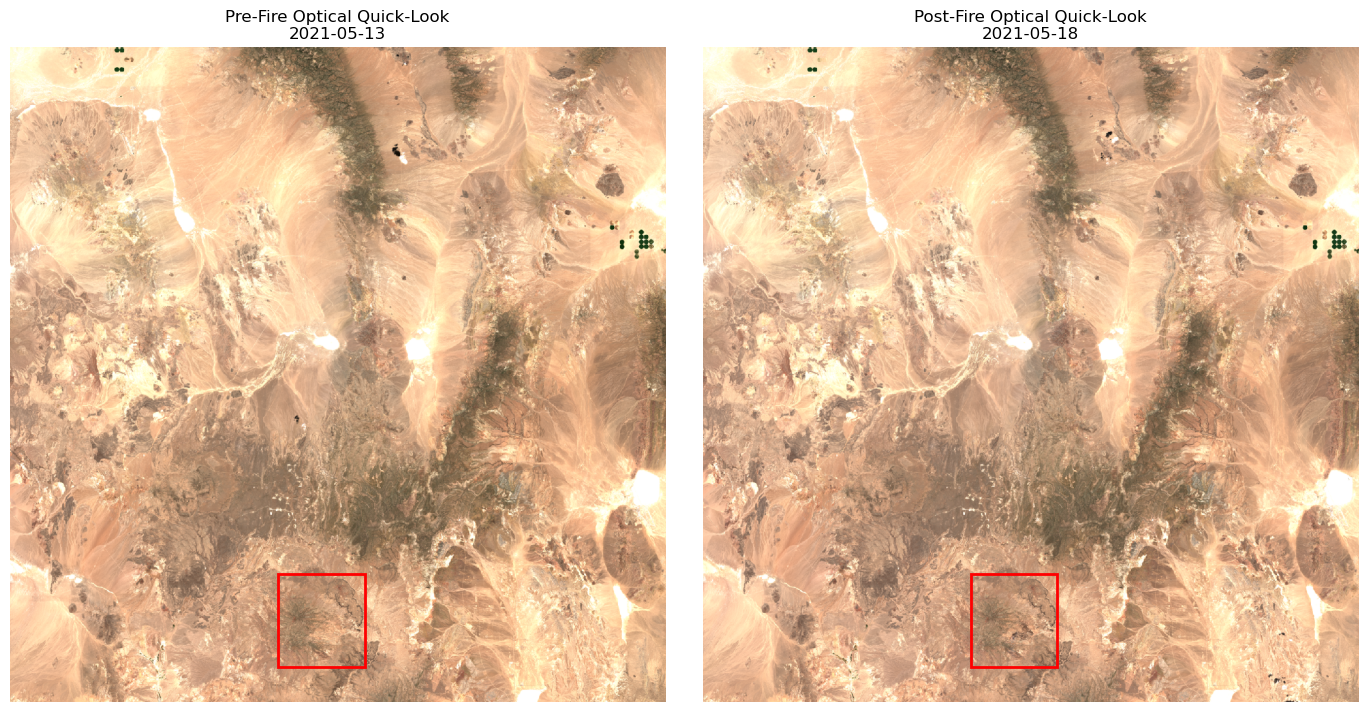

In [97]:
import io
import matplotlib.patches as patches

def inspect_s2_optical_images_with_bounds(candidate, target_bbox):
    """
    Displays a visual preview for Sentinel-2 scenes and overlays a red bounding box representing the fire target zone.
    """
    print("Fetching previews and calculating bounding box overlays...")
    
    _, axes = plt.subplots(1, 2, figsize=(14, 7))
    possible_keys = ['rendered_preview', 'preview', 'thumbnail']
    
    # grab fire bounding box coords: [min_lon, min_lat, max_lon, max_lat]
    f_minx, f_miny, f_maxx, f_maxy = target_bbox
    
    for idx, (period, item_key) in enumerate([('Pre-Fire', 'pre_s2'), ('Post-Fire', 'post_s2')]):
        item = candidate[item_key]
        img_loaded = False
        
        # grab the satellite tile's total footprint coordinates
        t_minx, t_miny, t_maxx, t_maxy = item.bbox
        
        available_keys = [k for k in possible_keys if k in item.assets]
        for key in available_keys:
            try:
                url = item.assets[key].href
                response = requests.get(url, timeout=15)
                
                if response.status_code == 200 and 'image' in response.headers.get('Content-Type', ''):
                    img = Image.open(io.BytesIO(response.content))
                    axes[idx].imshow(img)
                    
                    # convert image size to numpy dimensions
                    img_w, img_h = img.size 
                    
                    # calculate relative position of fire bounds within the tile (0.0 to 1.0)
                    pixel_minx = ((f_minx - t_minx) / (t_maxx - t_minx)) * img_w
                    pixel_maxx = ((f_maxx - t_minx) / (t_maxx - t_minx)) * img_w
                    pixel_miny = (1.0 - (f_maxy - t_miny) / (t_maxy - t_miny)) * img_h
                    pixel_maxy = (1.0 - (f_miny - t_miny) / (t_maxy - t_miny)) * img_h
                    
                    box_width = pixel_maxx - pixel_minx
                    box_height = pixel_maxy - pixel_miny
                    
                    # creat the red outline of the fire
                    rect = patches.Rectangle(
                        (pixel_minx, pixel_miny), 
                        box_width, 
                        box_height, 
                        linewidth=2, 
                        edgecolor='red', 
                        facecolor='none',
                        label='Target Zone'
                    )
                    axes[idx].add_patch(rect)
                    
                    # polish it up 
                    axes[idx].set_title(f"{period} Optical Quick-Look\n{candidate[item_key+'_time'].strftime('%Y-%m-%d')}")
                    axes[idx].axis('off')
                    img_loaded = True
                    break
            except Exception as e:
                continue
                
        if not img_loaded:
            axes[idx].text(0.5, 0.5, "Failed to load preview images", ha='center', va='center')
            axes[idx].axis('off')
            
    plt.tight_layout()
    plt.show()

# Run the updated overlay function
inspect_s2_optical_images_with_bounds(current_choice, stac_boundary_box)

### Download full Sentinel scenes

We will retrieve the raw SAFE files from the [Copernicus Data Space Portal](https://dataspace.copernicus.eu/) and then send them straight to our S3 blob.

First step is to extract the tile ID and platform from each Sentinel-2 STAC item and query the CSDE cloud database to locate the matching data package.

In [100]:
def pinpoint_s2_scene_on_cdse(stac_item):
    """
    Finds a scene on CDSE by extracting metadata properties directly
    from the STAC item object to avoid string splitting errors.
    """
    # pull properties natively from the STAC item metadata and standardize platform name
    tile_id = stac_item.properties.get("s2:mgrs_tile")     
    platform = stac_item.properties.get("platform")        
    platform_code = "S2A" if "A" in platform else "S2B"
    
    # extract the exact acquisition date and format as YYYY-MM-DD
    acq_time = stac_item.datetime
    date_str = acq_time.strftime("%Y-%m-%d")
    
    # construct the structural CDSE query using the clean parameters
    query_url = (
        "https://catalogue.dataspace.copernicus.eu/odata/v1/Products?"
        f"$filter=Collection/Name eq 'SENTINEL-2' and "
        f"Attributes/OData.CSC.StringAttribute/any(att:att/Name eq 'tileId' and att/att/Value eq '{tile_id}') and "
        f"ContentDate/Start ge {date_str}T00:00:00.000Z and "
        f"ContentDate/Start le {date_str}T23:59:59.999Z"
    )
    
    print(f"Querying CDSE catalog for tile {tile_id} ({platform_code}) at the date {date_str}...")
    response = requests.get(query_url, timeout=15).json()

    raw_matches = response.get('value', [])
    if not raw_matches:
        print("No matches found in the raw query. Double check your date boundaries or tile extraction.")
        return None
    
    # filter list comp to only accept official Sentinel Level-2A products
    l2a_matches = [prod for prod in raw_matches if "_MSIL2A_" in prod['Name']]
    
    if not l2a_matches:
        print("Matches were found, but none of them passed the Level-2A (MSIL2A) validation filter.")
        return None
        
    for idx, product in enumerate(l2a_matches):
        print(f"[Match {idx+1}] Located Verified L2A Scene on Copernicus Servers:")
        print(f"Official Name: {product['Name']}")
        print(f"CDSE UUID: {product['Id']}")
        print(f"Data Size: {product['ContentLength'] / (1024**2):.2f} MB")
        
    # Return the first matching L2A product payload
    return l2a_matches[0]


In [101]:
print("Locating Sentinel-2 pre fire scene.")
s2_pre_product = pinpoint_s2_scene_on_cdse(final_pre_s2_item)
print("Locating Sentinel-2 post fire scene.")
s2_post_product = pinpoint_s2_scene_on_cdse(final_post_s2_item)

Locating Sentinel-2 pre fire scene.
Querying CDSE catalog for tile 11SNB (S2A) at the date 2021-05-13...
[Match 1] Located Verified L2A Scene on Copernicus Servers:
Official Name: S2A_MSIL2A_20210513T182921_N0500_R027_T11SNB_20230206T155918.SAFE
CDSE UUID: 88ebee79-f5a4-4c47-ba8d-893164d72dbb
Data Size: 1088.25 MB
Locating Sentinel-2 post fire scene.
Querying CDSE catalog for tile 11SNB (S2B) at the date 2021-05-18...
[Match 1] Located Verified L2A Scene on Copernicus Servers:
Official Name: S2B_MSIL2A_20210518T182919_N0500_R027_T11SNB_20230224T005916.SAFE
CDSE UUID: a768b26b-fbb4-46a2-94ab-d8d065119537
Data Size: 1096.93 MB


Next is to use string IDs to match Sentinel-1 STAC item and to the SAFE folder living somewhere in the CSDE cloud database, then retrieve and download the matching data package.

In [102]:
def pinpoint_s1_scene_on_cdse(stac_item):
    """
    Finds the exact matching Sentinel-1 GRD COG scene on CDSE by extraction
    of the immutable product identifier fingerprint from the STAC ID.
    """
    stac_id = stac_item.id
    
    # extract the core unique string segment of the scene
    id_parts = stac_id.split('_')
    core_fingerprint = "_".join(id_parts[:8]) 
    
    # query CDSE catalog directly for any COG package containing this exact string sequence
    query_url = (
        "https://catalogue.dataspace.copernicus.eu/odata/v1/Products?"
        f"$filter=Collection/Name eq 'SENTINEL-1' and "
        f"contains(Name, '{core_fingerprint}') and "
        f"contains(Name, '_COG')"
    )
    
    print(f"Querying CDSE using unique identifier track: {core_fingerprint}...")
    response = requests.get(query_url, timeout=15).json()
    
    valid_matches = response.get('value', [])
    if not valid_matches:
        print("Direct fingerprint match failed. Ensure the source STAC ID is valid.")
        return None
        
    chosen_product = valid_matches[0]

    if "_1SDV_" not in chosen_product['Name'] and "_1SDH_" not in chosen_product['Name']:
        print(f"WARNING: CDSE product '{chosen_product['Name']}' does not look dual-pol "
              f"(expected _1SDV_ or _1SDH_ in the name). Skipping.")
        return None
    
    print("Verified S1 Scene Isolated Successfully:")
    print(f"Name: {chosen_product['Name']}")
    print(f"UUID: {chosen_product['Id']}")
    print(f"Size: {chosen_product['ContentLength'] / (1024**2):.2f} MB")
    
    return chosen_product

In [103]:
print("Locating Sentinel-1 pre fire scene.")
s1_pre_product = pinpoint_s1_scene_on_cdse(final_pre_s1_item)
print("Locating Sentinel-1 post fire scene.")
s1_post_product = pinpoint_s1_scene_on_cdse(final_post_s1_item)

Locating Sentinel-1 pre fire scene.
Querying CDSE using unique identifier track: S1A_IW_GRDH_1SDV_20210513T134336_20210513T134401_037870_047833...
Verified S1 Scene Isolated Successfully:
Name: S1A_IW_GRDH_1SDV_20210513T134336_20210513T134401_037870_047833_C1B9_COG.SAFE
UUID: 9d084268-8961-41a3-8a96-8030acb1d4b7
Size: 1165.07 MB
Locating Sentinel-1 post fire scene.
Querying CDSE using unique identifier track: S1A_IW_GRDH_1SDV_20210518T135149_20210518T135214_037943_047A68...
Verified S1 Scene Isolated Successfully:
Name: S1A_IW_GRDH_1SDV_20210518T135149_20210518T135214_037943_047A68_1C38_COG.SAFE
UUID: 0aeda077-5fc6-4b0a-891d-5da54a80ac76
Size: 1146.33 MB


### Download ERA5 Data
Download the ERA5 temporal data from the Copernicus Climate Data Store

In [104]:
import math
from shapely.geometry import shape

def calculate_master_era5_area(cdse_products, padding_degrees=2):
    """
    Takes a list of CDSE product dictionaries, extracts their geographic footprints,
    and returns a single unified floor/ceil ERA5 area envelope [North, West, South, East].
    Pads the rounded envelope by padding_degrees on every side -- the catalog GeoFootprint
    isn't always a tight superset of the actual downloaded raster's footprint (seen ~0.1-0.2
    degree overshoots), and ERA5 is cheap enough that a generous margin costs nothing.
    """
    all_min_lon = []
    all_max_lon = []
    all_min_lat = []
    all_max_lat = []
    
    for product in cdse_products:
        if isinstance(product, dict) and 'GeoFootprint' in product:
            # Parse the GeoJSON footprint directly into a Shapely geometry
            geom_bounds = shape(product['GeoFootprint']).bounds
            
            all_min_lon.append(geom_bounds[0])
            all_min_lat.append(geom_bounds[1])
            all_max_lon.append(geom_bounds[2])
            all_max_lat.append(geom_bounds[3])
        else:
            raise ValueError("Invalid input: Expected a CDSE product dictionary containing 'GeoFootprint'.")
            
    # Calculate the absolute outer bounding thresholds matching ERA5 standards, then pad outward
    master_era5_area = [
        math.ceil(max(all_max_lat)) + padding_degrees,    # North
        math.floor(min(all_min_lon)) - padding_degrees,   # West
        math.floor(min(all_min_lat)) - padding_degrees,   # South
        math.ceil(max(all_max_lon)) + padding_degrees     # East
    ]

    print(f"Spatial Envelope Rounded + Padded Coordinates [N, W, S, E]: {master_era5_area}")
    
    return master_era5_area


In [105]:
import cdsapi
def download_antecedent_era5(era5_area, s3_client, bucket_name, s3_folder_prefix, state_code, coord_str):
    """
    Downloads ERA5 GRIB to /tmp then streams directly to S3.
    """
    ignition_datetime = pd.to_datetime(ignition_date)
    start_date = ignition_datetime - timedelta(days=30)
    
    print(f"True Ignition Date: {ignition_datetime.strftime('%Y-%m-%d')}")
    print(f"30-Day Data Collection Window: {start_date.strftime('%Y-%m-%d')} to {ignition_datetime.strftime('%Y-%m-%d')}")
    
    curr_year = ignition_datetime.strftime("%Y")
    curr_month = ignition_datetime.strftime("%m")
    prev_month_date = ignition_datetime - pd.DateOffset(months=1)
    prev_month = prev_month_date.strftime("%m")
    prev_month_year = prev_month_date.strftime("%Y")
    
    years_list = list(set([curr_year, prev_month_year]))
    months_list = [prev_month, curr_month]
    days_list = [f"{d:02d}" for d in range(1, 32)]
    
    c = cdsapi.Client(quiet=True)
    
    era5_timestamp = ignition_datetime.strftime('%Y%m%d')
    era5_filename = f"ERA5_{state_code.upper()}_{coord_str}_{era5_timestamp}.grib"
    era5_s3_key = f"{s3_folder_prefix}{era5_filename}"
    tmp_path = f"/tmp/{era5_filename}"
    
    request_params = {
        'product_type': 'reanalysis',
        'format': 'grib',
        'variable': [
            '10m_u_component_of_wind', 
            '10m_v_component_of_wind', 
            '2m_dewpoint_temperature',
            '2m_temperature', 
            'total_precipitation'
        ],
        'year': list(years_list),
        'month': list(months_list),
        'day': sorted(list(days_list)),
        'time': [f'{h:02d}:00' for h in range(24)],
        'area': era5_area,
    }
    
    print("Transmitting download request token to Copernicus Climate Data Store...")
    c.retrieve('reanalysis-era5-single-levels', request_params, tmp_path)
    print(f"ERA5 GRIB downloaded to {tmp_path}, streaming to S3...")

    file_size = os.path.getsize(tmp_path)
    progress = ProgressPercentage(era5_filename, file_size)
    
    s3_client.upload_file(
        Filename=tmp_path,
        Bucket=bucket_name,
        Key=era5_s3_key,
        ExtraArgs={'ExpectedBucketOwner': '202802195212'},
        Callback=progress
    )
    progress.close()
    os.remove(tmp_path)
    
    return era5_filename

In [106]:
active_products = [s1_pre_product, s1_post_product, s2_pre_product, s2_post_product]
master_era5_area = calculate_master_era5_area(active_products)

Spatial Envelope Rounded Coordinates [N, W, S, E]: [38, -119, 35, -113]


# Send Sentinel Products and ERA5 Grib to S3 Bucket

In order to skip saving large Sentinel SAFE files onto my local, I will send them directly to an S3 bucket that will hold my entire wildfire prediction dataset. The ERA5 data must be sent from local since I need to download the GRIB folder and verify myself that the timesteps, geographic coordinates, and downloaded variables are correct.

In [107]:
def format_coordinate_strings(stac):
    """
    Translates the fire's MTBS boundary box [min_long, min_lat, max_long, max_lat]
    into a unified coordinate tracking string. 
    """
    min_long, min_lat, max_long, max_lat = stac

    # calculate the centroid of the fire 
    center_lat = (min_lat + max_lat) / 2.0
    center_lon = (min_long + max_long) / 2.0

    lat_suffix = 'N' if center_lat >= 0 else 'S'
    lon_suffix = 'E' if center_lon >= 0 else 'W'

    # round to the nearest integer matching 
    lat_val = abs(int(round(center_lat)))
    lon_val = abs(int(round(center_lon)))

    return f"{lat_val}{lat_suffix}{lon_val}{lon_suffix}"

In [108]:
def get_cdse_token():
    """
    Generate and retrieve an access token from the Copernicus Dataspace Ecosystem.
    """
    auth_url = "https://identity.dataspace.copernicus.eu/auth/realms/CDSE/protocol/openid-connect/token"
    payload = {
        'client_id': 'cdse-public',
        'grant_type': 'password',
        'username': os.getenv("CDSE_EMAIL"),
        'password': os.getenv("CDSE_PASSWORD")
    }
    
    response = requests.post(auth_url, data=payload)
    response.raise_for_status()
    return response.json()['access_token']

In [109]:
import json
import os

def create_and_upload_metadata(
    s3_client,
    state,
    fire_name,
    mtbs_event_id,
    mtbs_post_id,
    spatial_bounds,
    uploaded_files,
    spatial_coverage,  
    bucket_name,
    bucket_owner_id,
):
    """Creates a local metadata.json file containing filename mappings

    and explicit spatial coverage constraints, then uploads to S3.
    """
    # Force ERA5 tracking metrics to 100% boundary containment
    spatial_coverage["ERA5"] = 100.0

    metadata = {
        "event_id": mtbs_event_id,
        "fire_name": fire_name,
        "state": state,
        "mtbs_post_id": mtbs_post_id,
        "spatial_bounds": spatial_bounds,
        "spatial_coverage": spatial_coverage,  
        "contents": uploaded_files,
    }

    local_filename = f"{fire_name}_metadata.json"
    s3_key = f"fires/{state}/{fire_name}/metadata.json"

    try:
        with open(local_filename, "w") as f:
            json.dump(metadata, f, indent=4)

        extra_args = {
            "ContentType": "application/json",
            "ExpectedBucketOwner": bucket_owner_id,
        }

        print(f"Syncing metadata to s3://{bucket_name}/{s3_key}...")

        s3_client.upload_file(
            Filename=local_filename,
            Bucket=bucket_name,
            Key=s3_key,
            ExtraArgs=extra_args,
        )
        print(f" Metadata successfully synchronized for {fire_name}!")

    except Exception as e:
        print(f"Failed to process metadata for {fire_name}. Error: {e}")

    finally:
        if os.path.exists(local_filename):
            os.remove(local_filename)

In [110]:
from concurrent.futures import ThreadPoolExecutor, as_completed

def stream_product_to_s3(key, product, s3_client, bucket_name, s3_folder_prefix, state_code, config):
    source, phase = key.split('_')
    raw_time = product['ContentDate']['Start'].replace('Z', '')
    timestamp_str = pd.to_datetime(raw_time).strftime("%Y%m%d")
    coord_str = format_coordinate_strings(stac_boundary_box)
    s3_filename = f"{source}_{state_code.upper()}_{coord_str}_{timestamp_str}_{phase}.SAFE"
    s3_key = f"{s3_folder_prefix}{s3_filename}"

    s3_path = product.get('S3Path')
    if s3_path and s3_path.startswith('/eodata/'):
        download_url = f"https://zipper.dataspace.copernicus.eu/odata/v1/Products({product['Id']})/$value"
    else:
        download_url = s3_path or f"https://zipper.dataspace.copernicus.eu/odata/v1/Products({product['Id']})/$value"

    access_token = get_cdse_token()  # move inside so each thread gets its own token
    headers = {'Authorization': f'Bearer {access_token}'}

    with requests.get(download_url, headers=headers, stream=True, timeout=120) as response:
        response.raise_for_status()
        total_size = int(response.headers.get('content-length', 0))
        progress = ProgressPercentage(s3_filename, total_size)
        s3_client.upload_fileobj(
            Fileobj=response.raw,
            Bucket=bucket_name,
            Key=s3_key,
            ExtraArgs={'ExpectedBucketOwner': '202802195212'},
            Callback=progress,
            Config=config
        )
        progress.close()
    
    return key, s3_filename

In [111]:
import boto3
from boto3.s3.transfer import TransferConfig
from tqdm.notebook import tqdm

class ProgressPercentage(object):
    """Tracks upload progress callback for boto3."""
    def __init__(self, filename, total_size):
        self._filename = filename
        self._size = total_size
        self._pbar = tqdm(
            desc=f"📤 Uploading {filename}",
            total=total_size,
            unit='B',
            unit_scale=True,
            unit_divisor=1024, 
            position=None,
            leave=True
        )

    def __call__(self, bytes_amount):
        self._pbar.update(bytes_amount)
        
    def close(self):
        self._pbar.close()

def upload_to_s3(
        cdse_products_dict,
        era5_area,
        state_code,
        fire_name,
        bucket_name="wildfire-scenes-s3-202802195212-eu-central-1-an"
):
    s3_client = boto3.client('s3')
    coord_str = format_coordinate_strings(stac_boundary_box)
    uploaded_assets = {}
    full_fire_name = f"{fire_name.upper()}_fire"
    s3_folder_prefix = f"fires/{state_code.upper()}/{full_fire_name}/"
    print(f"Starting cloud sync to s3 folder: s3://{bucket_name}/{s3_folder_prefix}")

    config = TransferConfig(
        multipart_threshold=1024 * 1024 * 16,
        multipart_chunksize=1024 * 1024 * 16,
        max_concurrency=4,
        use_threads=True,
        max_io_queue=100,
        io_chunksize=1024 * 1024 * 2,
    )

    with ThreadPoolExecutor(max_workers=5) as executor:
        futures = {
            executor.submit(
                stream_product_to_s3, key, product, s3_client,
                bucket_name, s3_folder_prefix, state_code, config
            ): key
            for key, product in cdse_products_dict.items()
        }

        # ERA5 as 5th concurrent task
        era5_future = executor.submit(
            download_antecedent_era5, era5_area, s3_client,
            bucket_name, s3_folder_prefix, state_code, coord_str
        )
        futures[era5_future] = 'ERA5'

        for future in as_completed(futures):
            key = futures[future]
            if key == 'ERA5':
                era5_filename = future.result()
                uploaded_assets['ERA5'] = era5_filename
                print(f"✓ ERA5 complete: {era5_filename}")
            else:
                k, s3_filename = future.result()
                uploaded_assets[k] = s3_filename
                print(f"✓ {k} complete: {s3_filename}")

    create_and_upload_metadata(
        s3_client=s3_client,
        state=state_code.upper(),
        fire_name=full_fire_name,
        mtbs_event_id=fire_id_string,
        mtbs_post_id=post_id_string,
        spatial_bounds=stac_boundary_box,
        spatial_coverage=coverages,
        uploaded_files=uploaded_assets,
        bucket_name=bucket_name,
        bucket_owner_id="202802195212"
    )

    print(f"S3 Storage Bundle Sync Complete for {fire_name.upper()} Fire dataset!")

In [112]:
import os

# Clear the variables forcing boto3 to look for local profile files
os.environ.pop("AWS_PROFILE", None)
os.environ.pop("AWS_DEFAULT_PROFILE", None)

print("Environment variables cleared! Ready for EC2 metadata role check.")

Environment variables cleared! Ready for EC2 metadata role check.


In [113]:
# Group your validated products with explicit labels
validated_cdse_matrix = {
    "S1_pre": s1_pre_product,
    "S1_post": s1_post_product,
    "S2_pre": s2_pre_product,
    "S2_post": s2_post_product
}

# Kick off streaming execution
upload_to_s3(
    cdse_products_dict=validated_cdse_matrix,
    era5_area=master_era5_area, 
    state_code=state_code,
    fire_name=fire_name                  
)

Starting cloud sync to s3 folder: s3://wildfire-scenes-s3-202802195212-eu-central-1-an/fires/NV/CHERRYWOOD_fire/
True Ignition Date: 2021-05-17
30-Day Data Collection Window: 2021-04-17 to 2021-05-17


Transmitting download request token to Copernicus Climate Data Store...


📤 Uploading S1_NV_37N116W_20210513_pre.SAFE:   0%|          | 0.00/1.14G [00:00<?, ?B/s]

📤 Uploading S1_NV_37N116W_20210518_post.SAFE:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

📤 Uploading S2_NV_37N116W_20210513_pre.SAFE:   0%|          | 0.00/1.06G [00:00<?, ?B/s]

...

✓ S2_post complete: S2_NV_37N116W_20210518_post.SAFE
✓ S1_pre complete: S1_NV_37N116W_20210513_pre.SAFE
✓ S1_post complete: S1_NV_37N116W_20210518_post.SAFE


7b19f54bfad0e3a026459a0dda00bbd.grib:   0%|          | 0.00/5.29M [00:00<?, ?B/s]

ERA5 GRIB downloaded to /tmp/ERA5_NV_37N116W_20210517.grib, streaming to S3...


📤 Uploading ERA5_NV_37N116W_20210517.grib:   0%|          | 0.00/5.29M [00:00<?, ?B/s]

✓ ERA5 complete: ERA5_NV_37N116W_20210517.grib
✓ S2_pre complete: S2_NV_37N116W_20210513_pre.SAFE
Syncing metadata to s3://wildfire-scenes-s3-202802195212-eu-central-1-an/fires/NV/CHERRYWOOD_fire/metadata.json...
 Metadata successfully synchronized for CHERRYWOOD_fire!
S3 Storage Bundle Sync Complete for CHERRYWOOD Fire dataset!
